# Project 1

## To do:
1. set up the domain x and y for the problem
2. set up approximation scheme for numerically solving for du/dt. Make sure to enforce proper boundary conditions!!! Note we are using central schemes on the boundaries too. 
3. conjugate gradient method to find steady state solution u
4. Using trasient solution, solve the heat equation. Enforece the same boundary conditions as before!

## Domain and parameters
- $\alpha$
- Nx 
- Ny
- L length of domain
- $\kappa$
- x, y using linspace

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import spdiags

In [ ]:
a = 0.005
Nx = 20
Ny = 20
L = 1

In [45]:
x = np.linspace(0, L, Nx+1) # +2 to include the boundary points
y = np.linspace(0, L, Ny+1) # we have Nx and Ny internal nodes
# easier to start by solving internal points and deal with BCs later

# meshgrid
[X, Y] = np.meshgrid(x, y)

k = 0.02 * np.exp(-((X-0.7)**2/0.09 + (Y-0.6)**2/0.25))

Text(0, 0.5, '$y$')

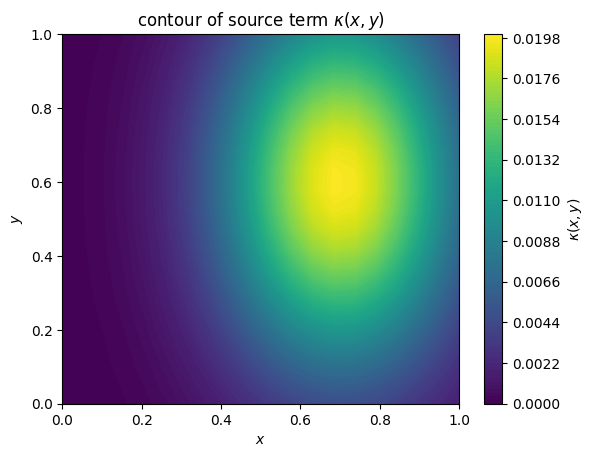

In [46]:
# countour of k
plt.contourf(X, Y, k, levels=100, cmap='viridis')
plt.title(r'contour of source term $\kappa(x,y)$')
plt.colorbar(label=r'$\kappa(x,y)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

In [47]:
dx = x[1] - x[0]
dy = y[1] - y[0]
dt = 0.01

In [48]:
index = np.arange(Nx * Ny).reshape(Ny, Nx).T 

In [49]:
k_flat = k.flatten(order='C') 

In [50]:
# boundary conditions
BCL_D = 0.5 - 0.5 * np.cos(2 * np.pi * y) # left boundary
BCR_N = np.zeros(len(y)) # right boundary
BCB_N = -0.3 * np.ones(len(x)) # bottom boundary
BCT_D = 0.5 + 0.5 * np.sin(2*np.pi * x - 0.5*np.pi) # top boundary

## Laplace Matrices

In [51]:
def laplace_mat(f, h, first_BC, last_BC):
    n = len(f)
    e = np.ones(n)

    # interior stencil
    mat = spdiags([e, -2 * e, e], [-1, 0, 1], n, n)
    mat = mat.toarray()

    mat = mat / h**2

    return mat

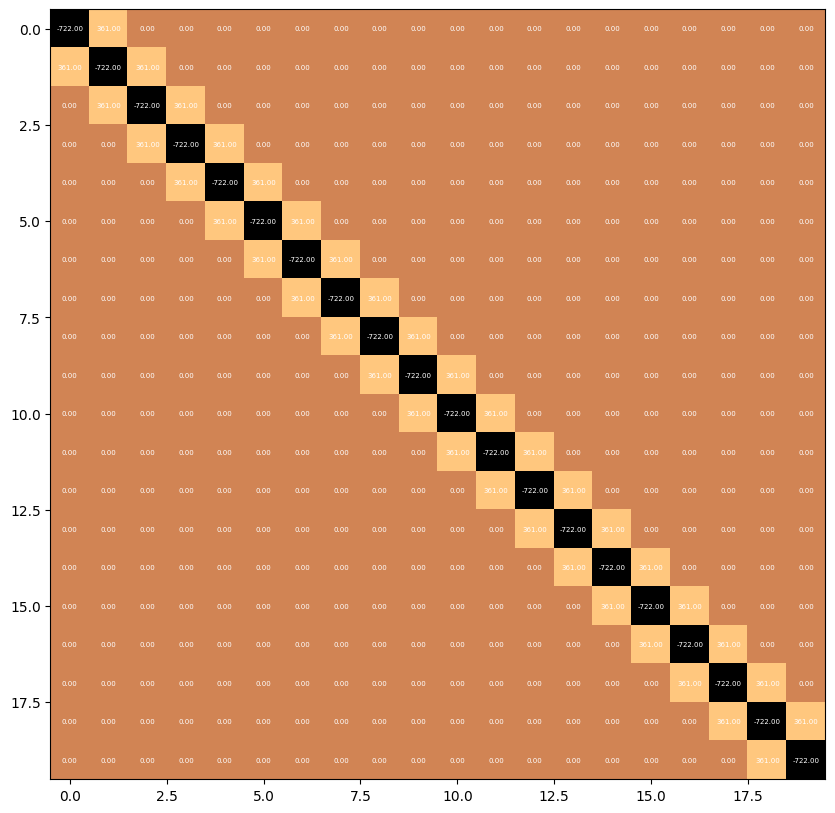

In [52]:
L2_x = laplace_mat(x, dx, BCL_D, BCR_N)
# plot matrix as heatmap
plt.figure(figsize=(10, 10))
plt.imshow(L2_x, cmap='copper', aspect='auto')
# show number in squares
for i in range(L2_x.shape[0]):
    for j in range(L2_x.shape[1]):
        plt.text(j, i, f'{L2_x[i, j]:.2f}', ha='center', va='center', color='white', fontsize=5)

In [53]:
def Laplace_u(u):
    value = np.zeros_like(u)
    # interior points
    for i in range(1, Ny-2):
        for j in range(1, Nx-2):
            # print(f'i={i}, j={j}')
            value[index[i, j]] = (u[index[i+1, j]] - 2 * u[index[i, j]] + u[index[i-1, j]]) / dx**2 \
                                + (u[index[i, j+1]] - 2 * u[index[i, j]] + u[index[i, j-1]]) / dy**2
    return value

# # left boundary
# for j in range(1, Ny-1):
#     i = 0
#     pass

In [54]:
# function for interior points laplace operator
def Laplace_u_interior(u):
    value = np.zeros_like(u)
    for i in range(1, Ny-1):
        for j in range(1, Nx-1):
            value[index[i, j]] = (u[index[i+1, j]] - 2 * u[index[i, j]] + u[index[i-1, j]]) / dx**2 \
                                + (u[index[i, j+1]] - 2 * u[index[i, j]] + u[index[i, j-1]]) / dy**2
    return value

Lx = Laplace_u_interior(x)

IndexError: index 21 is out of bounds for axis 0 with size 20

In [ ]:
A_LHS = @u a*Laplace_u(u)
RHS = -k - a*Laplace_BC()

U = np.linalg.solve(A_LHS, RHS)
USS = np.reshape(U, (Nx, Ny))

def Laplace_u(u):
    pass

def Laplace_BC():
    pass

In [ ]:
# heat equation

A_CN = lambda u: u - 0.5 * a * dt * Laplace_u(u)